In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

plt.rcParams['figure.dpi'] = 120
print('Libraries loaded ✅')

Libraries loaded ✅


## 1. Load the Dataset

In [2]:
movies  = pd.read_csv('movies.csv')
ratings = pd.read_csv('ratings.csv')
tags    = pd.read_csv('tags.csv')

print('movies :', movies.shape)
print('ratings:', ratings.shape)
print('tags   :', tags.shape)
print()
print('Unique users  :', ratings['userId'].nunique())
print('Unique movies :', ratings['movieId'].nunique())
print('Rating range  :', ratings['rating'].min(), '-', ratings['rating'].max())
print()
print('Rating distribution:')
print(ratings['rating'].value_counts().sort_index())

movies : (9742, 3)
ratings: (100836, 4)
tags   : (3683, 4)

Unique users  : 610
Unique movies : 9724
Rating range  : 0.5 - 5.0

Rating distribution:
rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64


## 2. Exploratory Overview

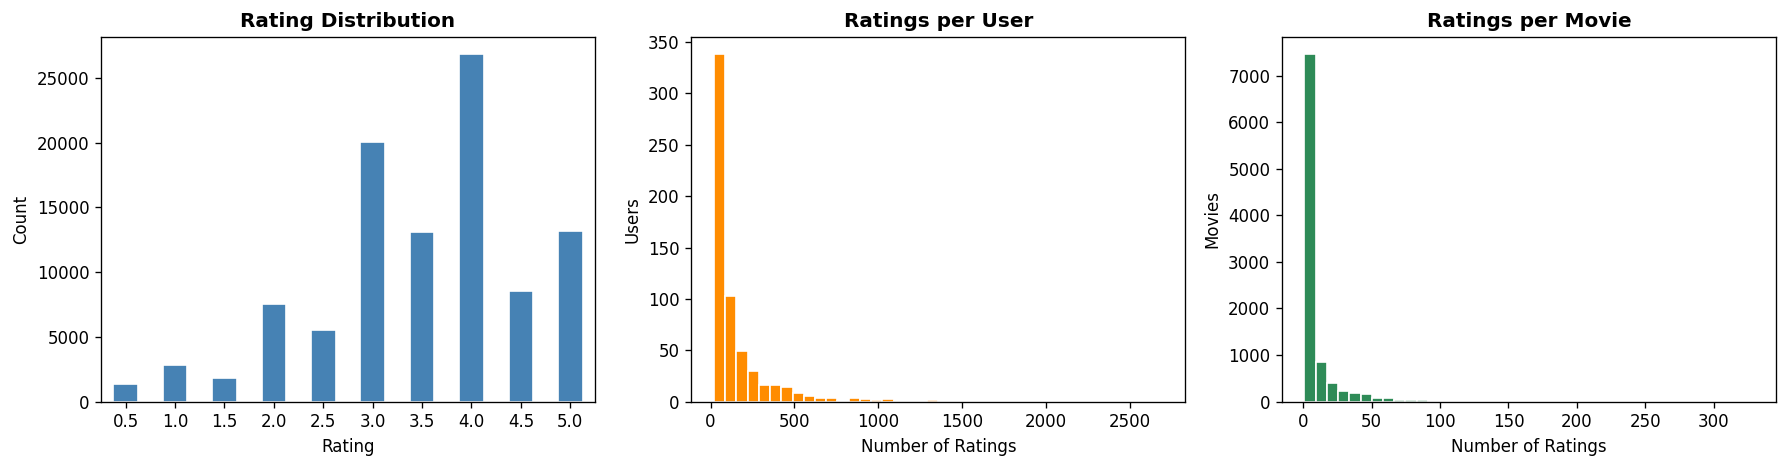

Avg ratings per user  : 165.3
Avg ratings per movie : 10.4
Most rated movie      : 356 — 329 ratings


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ratings['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Rating Distribution', fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

ratings_per_user = ratings.groupby('userId')['rating'].count()
axes[1].hist(ratings_per_user, bins=40, color='darkorange', edgecolor='white')
axes[1].set_title('Ratings per User', fontweight='bold')
axes[1].set_xlabel('Number of Ratings')
axes[1].set_ylabel('Users')

ratings_per_movie = ratings.groupby('movieId')['rating'].count()
axes[2].hist(ratings_per_movie, bins=40, color='seagreen', edgecolor='white')
axes[2].set_title('Ratings per Movie', fontweight='bold')
axes[2].set_xlabel('Number of Ratings')
axes[2].set_ylabel('Movies')

plt.tight_layout()
plt.show()

print(f'Avg ratings per user  : {ratings_per_user.mean():.1f}')
print(f'Avg ratings per movie : {ratings_per_movie.mean():.1f}')
print(f'Most rated movie      : {ratings_per_movie.idxmax()} — {ratings_per_movie.max()} ratings')

## 3. User-Item Matrix

In [4]:
user_movie = ratings.pivot_table(index='userId', columns='movieId', values='rating')

total_cells = user_movie.shape[0] * user_movie.shape[1]
filled_cells = user_movie.notna().sum().sum()
sparsity = (1 - filled_cells / total_cells) * 100

print(f'Matrix shape : {user_movie.shape}')
print(f'Filled cells : {filled_cells:,}')
print(f'Sparsity     : {sparsity:.1f}%')
user_movie.head()

Matrix shape : (610, 9724)
Filled cells : 100,836
Sparsity     : 98.3%


movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Train / Test Split

In [5]:
train, test = train_test_split(ratings, test_size=0.2, random_state=42)

train_matrix = train.pivot_table(index='userId', columns='movieId', values='rating')
train_filled = train_matrix.fillna(0)

print(f'Train ratings : {len(train)}')
print(f'Test ratings  : {len(test)}')
print(f'Train matrix  : {train_matrix.shape}')

Train ratings : 80668
Test ratings  : 20168
Train matrix  : (610, 8983)


## 5. User-Based Collaborative Filtering

In [6]:
user_sim = cosine_similarity(train_filled)
user_sim_df = pd.DataFrame(user_sim, index=train_matrix.index, columns=train_matrix.index)

print(f'User similarity matrix: {user_sim_df.shape}')
print(f'\nTop 5 most similar users to User 1:')
print(user_sim_df[1].drop(1).sort_values(ascending=False).head(5))

User similarity matrix: (610, 610)

Top 5 most similar users to User 1:
userId
266    0.324689
368    0.297333
45     0.288969
480    0.288702
217    0.282339
Name: 1, dtype: float64


In [7]:
def predict_user_based(user_id, movie_id, user_sim_df, user_matrix, n=10):
    if movie_id not in user_matrix.columns:
        return user_matrix.stack().mean()
    if user_id not in user_matrix.index:
        return user_matrix[movie_id].mean()

    sim_scores = user_sim_df[user_id].drop(user_id).sort_values(ascending=False).head(n)
    movie_ratings = user_matrix[movie_id][sim_scores.index].dropna()

    if len(movie_ratings) == 0:
        return user_matrix[movie_id].mean()

    weights = sim_scores[movie_ratings.index]
    if weights.sum() == 0:
        return user_matrix[movie_id].mean()

    return np.dot(weights, movie_ratings) / weights.sum()


def get_user_recommendations(user_id, user_sim_df, user_matrix, movies_df, n_similar=10, n_recs=10):
    if user_id not in user_matrix.index:
        return []

    similar_users = user_sim_df[user_id].drop(user_id).sort_values(ascending=False).head(n_similar).index
    watched = user_matrix.loc[user_id].dropna().index

    candidate_scores = {}
    for sim_user in similar_users:
        sim_score = user_sim_df[user_id][sim_user]
        user_ratings = user_matrix.loc[sim_user].dropna()
        for movie_id, rating in user_ratings.items():
            if movie_id not in watched:
                if movie_id not in candidate_scores:
                    candidate_scores[movie_id] = [0, 0]
                candidate_scores[movie_id][0] += sim_score * rating
                candidate_scores[movie_id][1] += sim_score

    recs = {mid: scores[0]/scores[1] for mid, scores in candidate_scores.items() if scores[1] > 0}
    top_recs = sorted(recs.items(), key=lambda x: x[1], reverse=True)[:n_recs]

    result = []
    for movie_id, score in top_recs:
        title = movies_df[movies_df['movieId'] == movie_id]['title'].values
        result.append({'movieId': movie_id, 'title': title[0] if len(title) else 'Unknown', 'predicted_rating': round(score, 3)})

    return pd.DataFrame(result)


print('Functions defined ✅')

Functions defined ✅


In [8]:
recs_user1 = get_user_recommendations(1, user_sim_df, train_matrix, movies)
print('Top 10 recommendations for User 1 (User-Based CF):')
print(recs_user1.to_string(index=False))

Top 10 recommendations for User 1 (User-Based CF):
 movieId                                       title  predicted_rating
     514                             Ref, The (1994)               5.0
    2300                       Producers, The (1968)               5.0
    2702                        Summer of Sam (1999)               5.0
    3060                     Commitments, The (1991)               5.0
    3265       Hard-Boiled (Lat sau san taam) (1992)               5.0
    1059 William Shakespeare's Romeo + Juliet (1996)               5.0
    1282                             Fantasia (1940)               5.0
    2078                     Jungle Book, The (1967)               5.0
    2083          Muppet Christmas Carol, The (1992)               5.0
    2106                           Swing Kids (1993)               5.0


## 6. Item-Based Collaborative Filtering

In [9]:
item_sim = cosine_similarity(train_filled.T)
item_sim_df = pd.DataFrame(item_sim, index=train_matrix.columns, columns=train_matrix.columns)

print(f'Item similarity matrix: {item_sim_df.shape}')

toy_story_id = 1
print(f'\nTop 5 movies similar to Toy Story (id=1):')
similar = item_sim_df[toy_story_id].drop(toy_story_id).sort_values(ascending=False).head(5)
for movie_id, score in similar.items():
    title = movies[movies['movieId'] == movie_id]['title'].values
    print(f'  {title[0] if len(title) else movie_id:<45} similarity={score:.4f}')

Item similarity matrix: (8983, 8983)

Top 5 movies similar to Toy Story (id=1):
  Back to the Future (1985)                     similarity=0.4695
  Lion King, The (1994)                         similarity=0.4628
  Shawshank Redemption, The (1994)              similarity=0.4596
  Star Wars: Episode VI - Return of the Jedi (1983) similarity=0.4582
  Forrest Gump (1994)                           similarity=0.4565


In [10]:
def get_item_recommendations(user_id, item_sim_df, user_matrix, movies_df, n_similar=10, n_recs=10):
    if user_id not in user_matrix.index:
        return []

    user_ratings = user_matrix.loc[user_id].dropna()
    watched = user_ratings.index.tolist()

    candidate_scores = {}
    for movie_id, rating in user_ratings.items():
        if movie_id not in item_sim_df.index:
            continue
        similar_movies = item_sim_df[movie_id].drop(movie_id, errors='ignore').sort_values(ascending=False).head(n_similar)
        for sim_movie, sim_score in similar_movies.items():
            if sim_movie not in watched:
                if sim_movie not in candidate_scores:
                    candidate_scores[sim_movie] = [0, 0]
                candidate_scores[sim_movie][0] += sim_score * rating
                candidate_scores[sim_movie][1] += sim_score

    recs = {mid: scores[0]/scores[1] for mid, scores in candidate_scores.items() if scores[1] > 0}
    top_recs = sorted(recs.items(), key=lambda x: x[1], reverse=True)[:n_recs]

    result = []
    for movie_id, score in top_recs:
        title = movies_df[movies_df['movieId'] == movie_id]['title'].values
        result.append({'movieId': movie_id, 'title': title[0] if len(title) else 'Unknown', 'predicted_rating': round(score, 3)})

    return pd.DataFrame(result)


print('Function defined ✅')

Function defined ✅


In [11]:
recs_item1 = get_item_recommendations(1, item_sim_df, train_matrix, movies)
print('Top 10 recommendations for User 1 (Item-Based CF):')
print(recs_item1.to_string(index=False))

Top 10 recommendations for User 1 (Item-Based CF):
 movieId                              title  predicted_rating
   44761                       Brick (2005)               5.0
     955            Bringing Up Baby (1938)               5.0
    4662   See No Evil, Hear No Evil (1989)               5.0
    1387                        Jaws (1975)               5.0
    4226                     Memento (2000)               5.0
    3275        Boondock Saints, The (2000)               5.0
    3990 Rugrats in Paris: The Movie (2000)               5.0
    8874           Shaun of the Dead (2004)               5.0
    2014               Freaky Friday (1977)               5.0
   44665         Lucky Number Slevin (2006)               5.0


## 7. Evaluation — RMSE

In [12]:
test_eval = test[
    test['userId'].isin(train_matrix.index) &
    test['movieId'].isin(train_matrix.columns)
].copy()

print(f'Test samples for evaluation: {len(test_eval)}')

preds_user  = []
preds_item  = []
actuals     = []

for row in test_eval.itertuples():
    pred_u = predict_user_based(row.userId, row.movieId, user_sim_df, train_matrix)
    preds_user.append(pred_u)

    if row.movieId in item_sim_df.index:
        sim_items = item_sim_df[row.movieId]
        rated = train_matrix.loc[row.userId].dropna()
        common = rated.index.intersection(sim_items.index)
        if len(common) > 0:
            w = sim_items[common]
            pred_i = np.dot(w, rated[common]) / w.sum() if w.sum() > 0 else train_matrix[row.movieId].mean()
        else:
            pred_i = train_matrix[row.movieId].mean()
    else:
        pred_i = train_matrix.stack().mean()

    preds_item.append(pred_i)
    actuals.append(row.rating)

rmse_user = np.sqrt(mean_squared_error(actuals, preds_user))
rmse_item = np.sqrt(mean_squared_error(actuals, preds_item))

print(f'\nUser-Based CF RMSE : {rmse_user:.4f}')
print(f'Item-Based CF RMSE : {rmse_item:.4f}')

Test samples for evaluation: 19355



User-Based CF RMSE : 1.0473
Item-Based CF RMSE : 0.9203


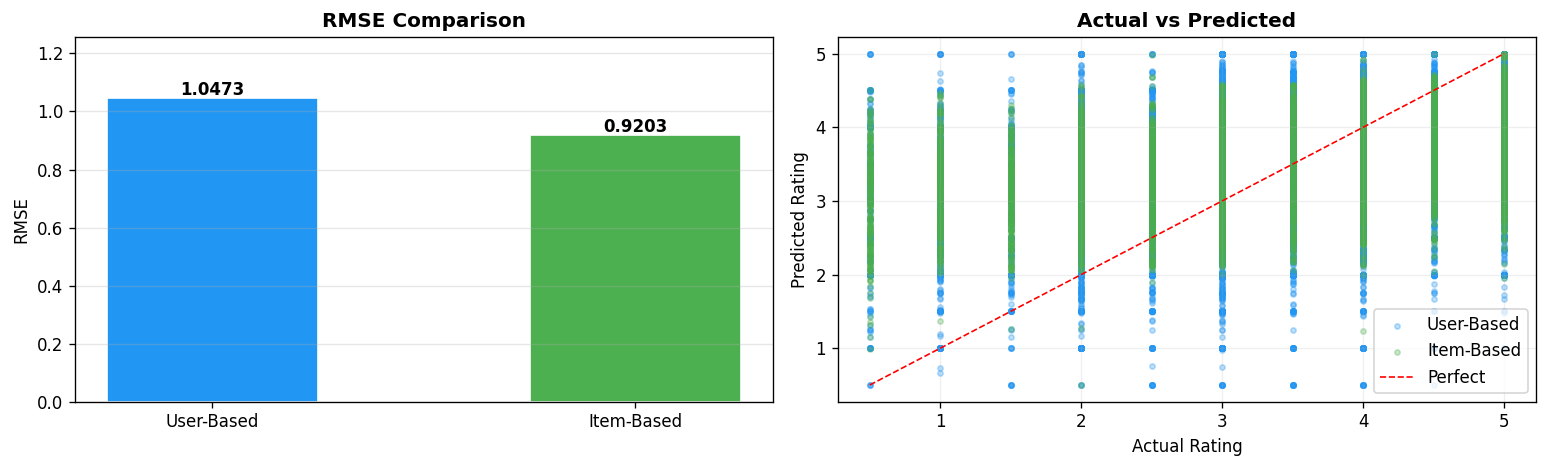

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(['User-Based', 'Item-Based'], [rmse_user, rmse_item],
            color=['#2196F3', '#4CAF50'], edgecolor='white', width=0.5)
for i, v in enumerate([rmse_user, rmse_item]):
    axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')
axes[0].set_title('RMSE Comparison', fontweight='bold')
axes[0].set_ylabel('RMSE')
axes[0].set_ylim(0, max(rmse_user, rmse_item) * 1.2)
axes[0].grid(axis='y', alpha=0.3)

axes[1].scatter(actuals, preds_user, alpha=0.3, s=10, color='#2196F3', label='User-Based')
axes[1].scatter(actuals, preds_item, alpha=0.3, s=10, color='#4CAF50', label='Item-Based')
axes[1].plot([0.5, 5], [0.5, 5], 'r--', linewidth=1, label='Perfect')
axes[1].set_xlabel('Actual Rating')
axes[1].set_ylabel('Predicted Rating')
axes[1].set_title('Actual vs Predicted', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 8. Similarity Heatmap

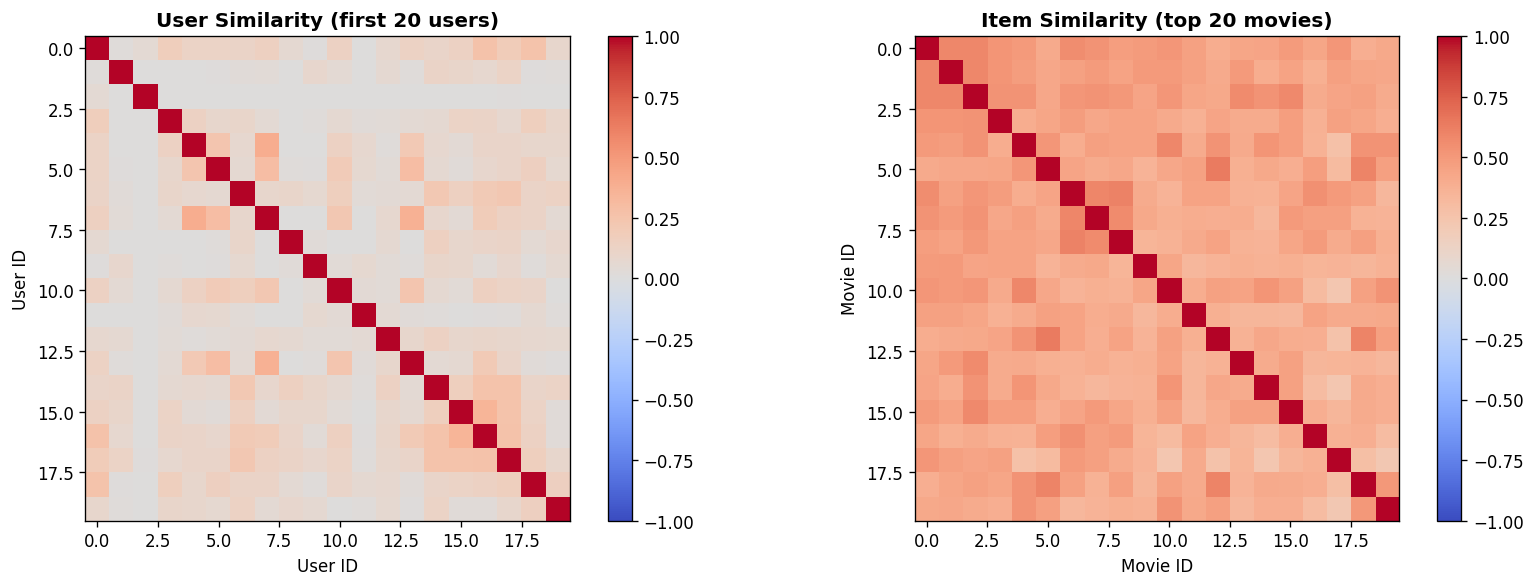

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

user_subset = user_sim_df.iloc[:20, :20]
im0 = axes[0].imshow(user_subset, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im0, ax=axes[0])
axes[0].set_title('User Similarity (first 20 users)', fontweight='bold')
axes[0].set_xlabel('User ID')
axes[0].set_ylabel('User ID')

popular_movies = ratings.groupby('movieId')['rating'].count().sort_values(ascending=False).head(20).index
item_subset = item_sim_df.loc[popular_movies, popular_movies]
im1 = axes[1].imshow(item_subset, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im1, ax=axes[1])
axes[1].set_title('Item Similarity (top 20 movies)', fontweight='bold')
axes[1].set_xlabel('Movie ID')
axes[1].set_ylabel('Movie ID')

plt.tight_layout()
plt.show()

## 9. User-Based vs Item-Based — Recommendation Comparison

In [15]:
print('User 1 — Movies already watched (sample):')
watched_ids = train_matrix.loc[1].dropna().sort_values(ascending=False).head(5).index
for mid in watched_ids:
    title = movies[movies['movieId'] == mid]['title'].values
    rating = train_matrix.loc[1, mid]
    print(f'  {title[0] if len(title) else mid:<45} rated: {rating}')

print()
print('User-Based recommendations:')
print(recs_user1[['title','predicted_rating']].to_string(index=False))

print()
print('Item-Based recommendations:')
print(recs_item1[['title','predicted_rating']].to_string(index=False))

User 1 — Movies already watched (sample):
  Newton Boys, The (1998)                       rated: 5.0
  Clockwork Orange, A (1971)                    rated: 5.0
  Crocodile Dundee (1986)                       rated: 5.0
  Thin Red Line, The (1998)                     rated: 5.0
  Rushmore (1998)                               rated: 5.0

User-Based recommendations:
                                      title  predicted_rating
                            Ref, The (1994)               5.0
                      Producers, The (1968)               5.0
                       Summer of Sam (1999)               5.0
                    Commitments, The (1991)               5.0
      Hard-Boiled (Lat sau san taam) (1992)               5.0
William Shakespeare's Romeo + Juliet (1996)               5.0
                            Fantasia (1940)               5.0
                    Jungle Book, The (1967)               5.0
         Muppet Christmas Carol, The (1992)               5.0
              

## 10. Summary / Comparison

In [16]:
summary = pd.DataFrame({
    'Method'          : ['User-Based CF', 'Item-Based CF'],
    'Similarity'      : ['User ↔ User (cosine)', 'Item ↔ Item (cosine)'],
    'Matrix Size'     : [str(user_sim_df.shape), str(item_sim_df.shape)],
    'RMSE'            : [round(rmse_user, 4), round(rmse_item, 4)],
    'Best for'        : ['New items, few items', 'Many items, stable catalogue'],
})

print('=' * 75)
print('  COLLABORATIVE FILTERING — SUMMARY')
print('=' * 75)
print(summary.to_string(index=False))
print('=' * 75)

  COLLABORATIVE FILTERING — SUMMARY
       Method           Similarity  Matrix Size   RMSE                     Best for
User-Based CF User ↔ User (cosine)   (610, 610) 1.0473         New items, few items
Item-Based CF Item ↔ Item (cosine) (8983, 8983) 0.9203 Many items, stable catalogue
